In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# Load cleaned data
df = pd.read_csv('../Data/processed/telco_cleaned.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 30)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Tenure Group,Avg Monthly Spend,Service Count,Contract_One year,Contract_Two year,Internet Service_Fiber optic,Internet Service_No,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,No,0,0,2,1,No,1,1,0,...,New (0-12mo),36.050000,3,False,False,False,False,False,False,True
1,0,No,0,1,2,1,No,0,0,0,...,New (0-12mo),50.550000,1,False,False,True,False,False,True,False
2,0,No,0,1,8,1,Yes,0,0,1,...,New (0-12mo),91.166667,4,False,False,True,False,False,True,False
3,0,No,1,1,28,1,Yes,0,0,1,...,Loyal (2-4yr),105.036207,5,False,False,True,False,False,True,False
4,1,No,0,1,49,1,Yes,0,1,1,...,Champion (4yr+),100.726000,5,False,False,True,False,False,False,False


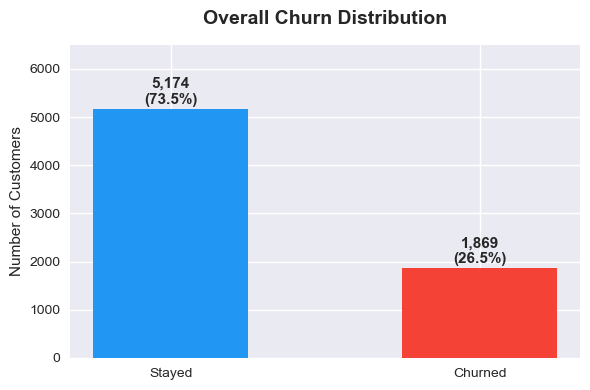


Insight: 26.5% churn rate means roughly 1 in 4 customers leaves.
This class imbalance will be important when we build our ML model.


In [2]:
# Plot 1: Overall Churn Distribution
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Churn Label'].value_counts()
colors = ['#2196F3', '#F44336']
bars = ax.bar(['Stayed', 'Churned'], churn_counts.values, color=colors, edgecolor='none', width=0.5)

# Add value labels on bars
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Overall Churn Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, 6500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: 26.5% churn rate means roughly 1 in 4 customers leaves.")
print("This class imbalance will be important when we build our ML model.")

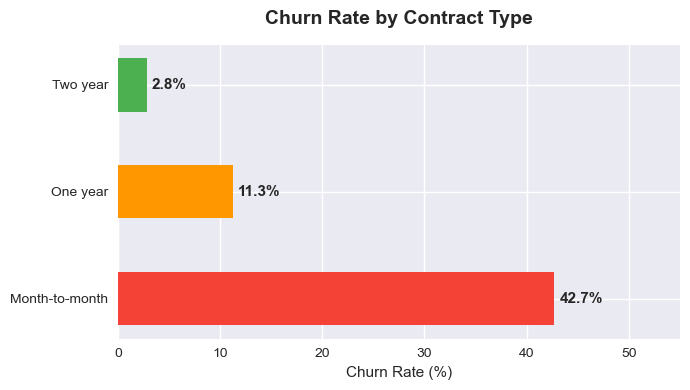

In [5]:
# Plot 2: Churn Rate by Contract Type
# Reconstruct contract type from encoded columns
def get_contract(row):
    if row['Contract_Two year'] == 1:
        return 'Two year'
    elif row['Contract_One year'] == 1:
        return 'One year'
    else:
        return 'Month-to-month'

df['Contract'] = df.apply(get_contract, axis=1)

contract_churn = df.groupby('Contract')['Churn Label'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))

colors = ['#F44336', '#FF9800', '#4CAF50']
bars = ax.barh(contract_churn.index, contract_churn.values, color=colors, edgecolor='none', height=0.5)

for bar, val in zip(bars, contract_churn.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

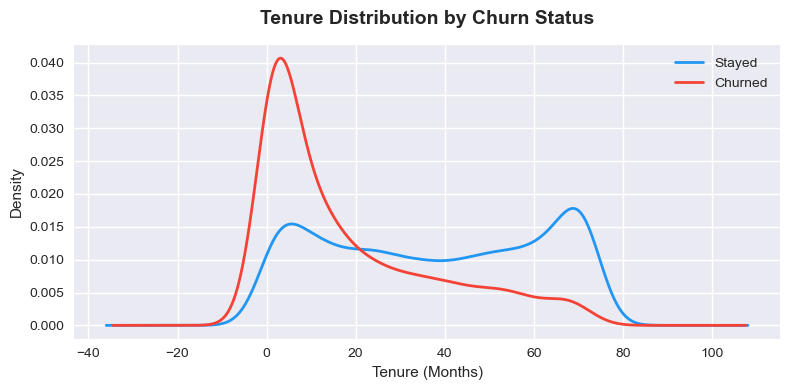


Insight: Churned customers cluster heavily in the first 0-20 months.
Customers who survive past month 20 are much less likely to churn.


In [6]:
# Plot 3: Tenure Distribution by Churn Status
fig, ax = plt.subplots(figsize=(8, 4))

for churn_val, label, color in [(0, 'Stayed', '#2196F3'), (1, 'Churned', '#F44336')]:
    subset = df[df['Churn Label'] == churn_val]['Tenure Months']
    subset.plot(kind='kde', ax=ax, label=label, color=color, linewidth=2)

ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Density')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/03_tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Churned customers cluster heavily in the first 0-20 months.")
print("Customers who survive past month 20 are much less likely to churn.")

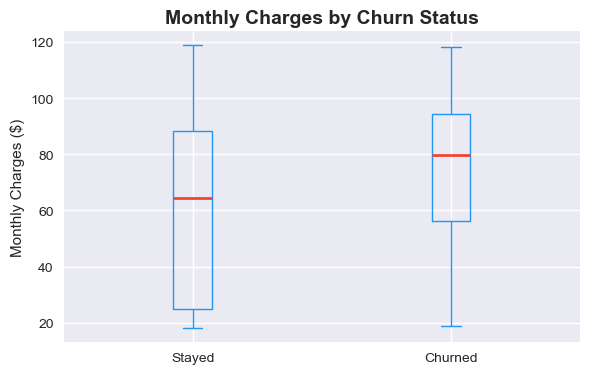


Insight: Churned customers pay $74.44/mo on average vs $61.27/mo for retained.
Higher charges are associated with churn — these customers feel they aren't getting value.


In [7]:
# Plot 4: Monthly Charges by Churn Status
fig, ax = plt.subplots(figsize=(6, 4))

df.boxplot(column='Monthly Charges', by='Churn Label', ax=ax,
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='#F44336', linewidth=2),
           whiskerprops=dict(color='#2196F3'),
           capprops=dict(color='#2196F3'))

ax.set_xticklabels(['Stayed', 'Churned'])
ax.set_title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Monthly Charges ($)')
plt.suptitle('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/04_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

stayed = df[df['Churn Label']==0]['Monthly Charges'].mean()
churned = df[df['Churn Label']==1]['Monthly Charges'].mean()
print(f"\nInsight: Churned customers pay ${churned:.2f}/mo on average vs ${stayed:.2f}/mo for retained.")
print("Higher charges are associated with churn — these customers feel they aren't getting value.")

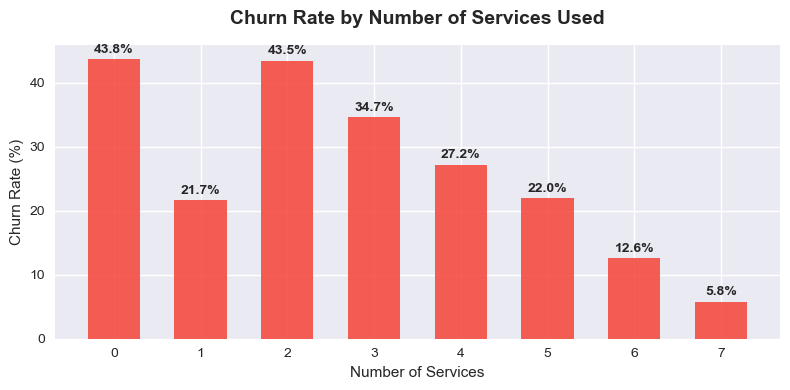


Insight: Customers with more services churn significantly less.
Add-on services increase switching cost and perceived value.


In [8]:
# Plot 5: Churn Rate by Service Count
service_churn = df.groupby('Service Count')['Churn Label'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(service_churn.index, service_churn.values, 
              color='#F44336', edgecolor='none', width=0.6, alpha=0.85)

for bar, val in zip(bars, service_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Churn Rate by Number of Services Used', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Services')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(service_churn.index)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/05_churn_by_service_count.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Customers with more services churn significantly less.")
print("Add-on services increase switching cost and perceived value.")

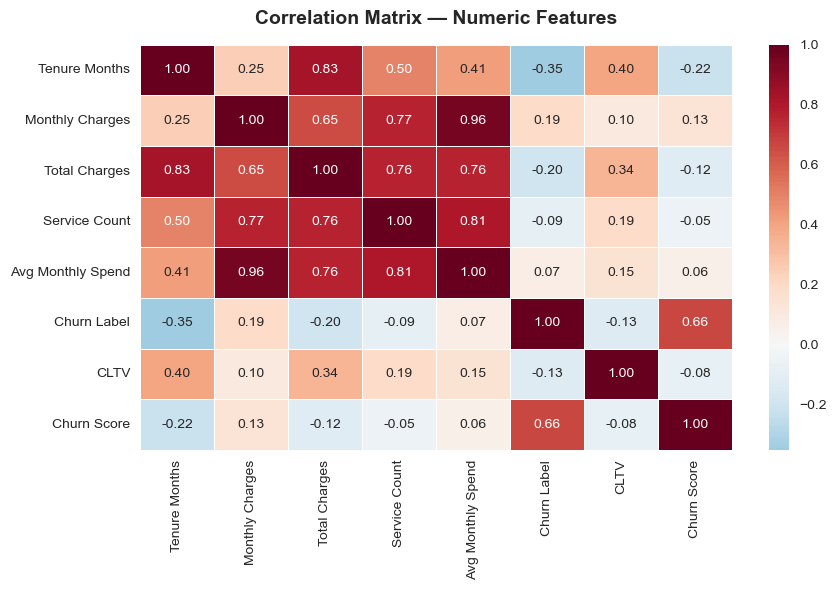


Insight: Tenure Months has a strong negative correlation with Churn (-0.35)
meaning longer-tenured customers are much less likely to churn.
Monthly Charges has a positive correlation — higher charges = more churn risk.


In [9]:
# Plot 6: Correlation Heatmap
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges',
            'Service Count', 'Avg Monthly Spend', 'Churn Label', 'CLTV', 'Churn Score']

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(df[num_cols].corr(), 
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5,
            annot_kws={'size': 10})

ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../reports/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Tenure Months has a strong negative correlation with Churn (-0.35)")
print("meaning longer-tenured customers are much less likely to churn.")
print("Monthly Charges has a positive correlation — higher charges = more churn risk.")

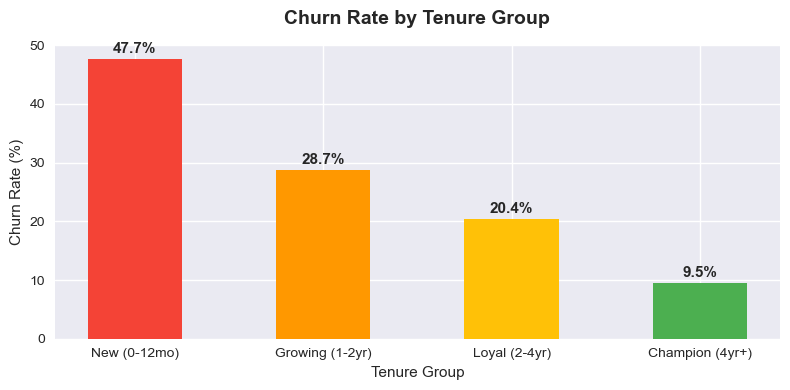


Insight: New customers (0-12 months) churn at the highest rate.
This points to an onboarding problem — customers leave before they see full value.


In [10]:
# Plot 7: Churn Rate by Tenure Group
df['Tenure Group'] = pd.cut(df['Tenure Months'],
    bins=[0, 12, 24, 48, 72],
    labels=['New (0-12mo)', 'Growing (1-2yr)', 'Loyal (2-4yr)', 'Champion (4yr+)'])

tenure_churn = df.groupby('Tenure Group', observed=True)['Churn Label'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']
bars = ax.bar(tenure_churn.index, tenure_churn.values, 
              color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/07_churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: New customers (0-12 months) churn at the highest rate.")
print("This points to an onboarding problem — customers leave before they see full value.")